# AI Load Balancer — XGBoost Training Pipeline
**Thesis:** Implementation of AI Based Load Balancing on Web Server Network using GNS3

---
### Struktur File yang Dibutuhkan
```
project/
├── xgboost_load_balancer.ipynb  ← file ini
├── final_RR_ws1.csv
├── final_RR_ws2.csv
├── final_LC_ws1.csv
├── final_LC_ws2.csv
├── Result_final_RR.csv
├── Result_Final_LC.csv
└── model/                       ← folder output (dibuat otomatis)
```
> `final_summary_RR.csv` dan `final_summary_LC.csv` **tidak dipakai** untuk training — hanya ringkasan statistik.

## Step 0 — Install & Import Library

In [106]:
# Install library yang dibutuhkan (jalankan sekali saja jika belum ter-install)
#!pip install xgboost scikit-learn pandas numpy matplotlib seaborn joblib

In [107]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

warnings.filterwarnings('ignore')
os.makedirs('model2', exist_ok=True)

print('✅ Semua library berhasil di-import.')

✅ Semua library berhasil di-import.


---
## Step 1 — Konfigurasi Path File CSV

In [108]:
# ============================================================
#  KONFIGURASI — sesuaikan path jika file berada di folder lain
# ============================================================

# File metrik server (format dool/dstat)
# LC Run 1: ramp-up lebih lambat (gradual)
PATH_LC1_WS1 = 'Dataset/metrics_WS1_1000T_300R.csv'   # ← sesuaikan nama file
PATH_LC1_WS2 = 'Dataset/metrics_WS2_1000T_300R.csv'

# LC Run 2: ramp-up lebih cepat
PATH_LC2_WS1 = 'Dataset/metrics_WS1_1000T_600R.csv'   # ← sesuaikan nama file
PATH_LC2_WS2 = 'Dataset/metrics_WS2_1000T_600R.csv'

# File log JMeter (raw HTTP request)
PATH_LC1_JM  = 'Dataset/hasil-1000T-300R-d-JM.csv'    # ← sesuaikan nama file
PATH_LC2_JM  = 'Dataset/hasil-1000T-600R-d-JM.csv'    # ← sesuaikan nama file

# Output model
PATH_MODEL  = 'model2/xgb_load_balancer.pkl'

print('✅ Konfigurasi siap.')


✅ Konfigurasi siap.


---
## Step 2 — Load & Parsing File Dool (Server Metrics)

File dool memiliki **5 baris header** sebelum data aktual dimulai.
Kolom aslinya: `usr, sys, idl, wai, stl, used, free, cach, avai, recv, send`

Yang kita butuhkan:
- **CPU_Usage_Percent** = `100 - idl` (CPU aktif)
- **RAM_Used_MB** = `used / 1024²`
- **Net_Recv_KB** = `recv / 1024`
- **Timestamp** = dibuat dari nomor baris (index ke-N = detik ke-N)

In [109]:
def load_dool(path, label=''):
    """
    Membaca file CSV dari dool (monitoring tool).
    - Skip 5 baris header dool
    - Hitung CPU aktif, RAM dalam MB, Network dalam KB
    - Buat kolom Timestamp dari index baris (detik ke-N)
    """
    # Baca CSV, lewati 5 baris header dool
    df = pd.read_csv(path, skiprows=5, header=0)

    # Berikan nama kolom yang jelas
    df.columns = [
        'cpu_usr', 'cpu_sys', 'cpu_idl', 'cpu_wai', 'cpu_stl',
        'mem_used_bytes', 'mem_free_bytes', 'mem_cach_bytes', 'mem_avai_bytes',
        'net_recv_bytes', 'net_send_bytes'
    ]

    # Konversi semua kolom ke numerik, paksa error jadi NaN
    df = df.apply(pd.to_numeric, errors='coerce')

    # Hapus baris yang semua kolomnya NaN (baris kosong atau header duplikat)
    df.dropna(how='all', inplace=True)
    df.reset_index(drop=True, inplace=True)

    # ── Hitung metrik yang dibutuhkan
    # CPU aktif = 100% dikurangi idle
    df['CPU_Usage_Percent'] = (100 - df['cpu_idl']).clip(0, 100)

    # RAM dalam MB
    df['RAM_Used_MB'] = df['mem_used_bytes'] / (1024 ** 2)

    # Network received dalam KB/s
    df['Net_Recv_KB'] = df['net_recv_bytes'] / 1024

    # Timestamp = index baris (tiap baris = 1 detik)
    df['Timestamp'] = df.index

    # Tandai sumber data — berguna untuk analisis distribusi
    df['source'] = label

    # Pilih hanya kolom yang relevan
    result = df[['Timestamp', 'CPU_Usage_Percent', 'RAM_Used_MB', 'Net_Recv_KB', 'source']].copy()

    # Isi missing values dengan median kolom
    for col in ['CPU_Usage_Percent', 'RAM_Used_MB', 'Net_Recv_KB']:
        result[col].fillna(result[col].median(), inplace=True)

    return result


# Load semua file server
lc1_ws1 = load_dool(PATH_LC1_WS1, label='LC1')  # LC run 1 (ramp-up lambat)
lc1_ws2 = load_dool(PATH_LC1_WS2, label='LC1')
lc2_ws1 = load_dool(PATH_LC2_WS1, label='LC2')  # LC run 2 (ramp-up cepat)
lc2_ws2 = load_dool(PATH_LC2_WS2, label='LC2')

print('=== Preview LC1 WS1 ===')
display(lc1_ws1.head())
print(f'\nJumlah baris → LC1 WS1: {len(lc1_ws1)} | LC1 WS2: {len(lc1_ws2)} | LC2 WS1: {len(lc2_ws1)} | LC2 WS2: {len(lc2_ws2)}')


=== Preview LC1 WS1 ===


,Timestamp,CPU_Usage_Percent,RAM_Used_MB,Net_Recv_KB,source
0,0,1.879,412.832031,0.00000,LC1
1,1,0.000,412.832031,3.81250,LC1
2,2,0.251,412.675781,0.00000,LC1
3,3,0.501,412.675781,32.84375,LC1
4,4,0.759,412.679688,175.81250,LC1



Jumlah baris → LC1 WS1: 356 | LC1 WS2: 356 | LC2 WS1: 671 | LC2 WS2: 671


---
## Step 3 — Load & Parsing File JMeter

Kolom asli JMeter: `timeStamp, elapsed, label, responseCode, responseMessage, threadName, success, Latency`

Penyesuaian:
- **Response_Time_ms** = kolom `elapsed`
- **Is_Error** = kebalikan dari `success` (True = sukses = **bukan** error → Is_Error = 0)

In [110]:
def load_jmeter(path, label=''):
    """
    Membaca file hasil JMeter.
    - Rename kolom 'elapsed' → 'Response_Time_ms'
    - Buat kolom 'Is_Error' dari kebalikan 'success'
    - Normalisasi Timestamp ke detik relatif (mulai dari 0)
    """
    df = pd.read_csv(path)

    # Rename kolom agar konsisten
    df.rename(columns={
        'elapsed'   : 'Response_Time_ms',
        'timeStamp' : 'ts_raw'
    }, inplace=True)

    # Is_Error = 1 jika request GAGAL (success=False atau success='false')
    # Tangani kemungkinan nilai string 'true'/'false'
    if df['success'].dtype == object:
        df['Is_Error'] = df['success'].str.lower().map({'true': 0, 'false': 1})
    else:
        df['Is_Error'] = (~df['success'].astype(bool)).astype(int)

    # Timestamp relatif dalam detik (mulai dari 0)
    df['Timestamp'] = ((df['ts_raw'] - df['ts_raw'].min()) / 1000).astype(int)

    df['source'] = label

    result = df[['Timestamp', 'Response_Time_ms', 'Is_Error', 'source']].copy()
    result.dropna(inplace=True)

    return result


# Load semua file JMeter
lc1_jm = load_jmeter(PATH_LC1_JM, label='LC1')
lc2_jm = load_jmeter(PATH_LC2_JM, label='LC2')

print('=== Preview LC1 JMeter ===')
display(lc1_jm.head())
print(f'\nJumlah request → LC1: {len(lc1_jm)} | LC2: {len(lc2_jm)}')
print(f'Error LC1 : {lc1_jm["Is_Error"].sum()} ({lc1_jm["Is_Error"].mean()*100:.2f}%)')
print(f'Error LC2 : {lc2_jm["Is_Error"].sum()} ({lc2_jm["Is_Error"].mean()*100:.2f}%)')


=== Preview LC1 JMeter ===


,Timestamp,Response_Time_ms,Is_Error,source
0,0,226,0,LC1
1,0,31,0,LC1
2,0,192,0,LC1
3,0,257,0,LC1
4,0,64,0,LC1



Jumlah request → LC1: 32000 | LC2: 32000
Error LC1 : 0 (0.00%)
Error LC2 : 0 (0.00%)


---
## Step 4 — Gabungkan (Concatenate) RR + LC

Semua data RR dan LC digabung menjadi satu dataset training.
Timestamp di-reset ulang agar tidak tumpang tindih antara RR dan LC.

In [111]:
def concat_and_reindex(df1, df2):
    """
    Gabungkan dua DataFrame dan reset Timestamp agar berurutan.
    LC1 mendapat Timestamp 0..N, LC2 mendapat Timestamp N+1..M.
    """
    offset = df1['Timestamp'].max() + 1
    df2 = df2.copy()
    df2['Timestamp'] = df2['Timestamp'] + offset
    combined = pd.concat([df1, df2], ignore_index=True)
    return combined


# Gabungkan WS1 (LC1 + LC2)
all_ws1 = concat_and_reindex(lc1_ws1, lc2_ws1)

# Gabungkan WS2 (LC1 + LC2)
all_ws2 = concat_and_reindex(lc1_ws2, lc2_ws2)

# Gabungkan JMeter (LC1 + LC2)
all_jm  = concat_and_reindex(lc1_jm,  lc2_jm)

print(f'Dataset gabungan:')
print(f'  WS1   : {len(all_ws1)} baris (LC1={len(lc1_ws1)} + LC2={len(lc2_ws1)})')
print(f'  WS2   : {len(all_ws2)} baris (LC1={len(lc1_ws2)} + LC2={len(lc2_ws2)})')
print(f'  JMeter: {len(all_jm)} request (LC1={len(lc1_jm)} + LC2={len(lc2_jm)})')

display(all_ws1.head())


Dataset gabungan:
  WS1   : 1027 baris (LC1=356 + LC2=671)
  WS2   : 1027 baris (LC1=356 + LC2=671)
  JMeter: 64000 request (LC1=32000 + LC2=32000)


,Timestamp,CPU_Usage_Percent,RAM_Used_MB,Net_Recv_KB,source
0,0,1.879,412.832031,0.00000,LC1
1,1,0.000,412.832031,3.81250,LC1
2,2,0.251,412.675781,0.00000,LC1
3,3,0.501,412.675781,32.84375,LC1
4,4,0.759,412.679688,175.81250,LC1


---
## Step 5 — Agregasi JMeter per Detik

In [112]:
# Ringkas JMeter per detik:
#   avg_rt     = rata-rata response time
#   total_req  = jumlah request
#   total_err  = jumlah request error
#   error_rate = proporsi error (0.0 - 1.0)
jm_agg = all_jm.groupby('Timestamp').agg(
    avg_rt    = ('Response_Time_ms', 'mean'),
    total_req = ('Response_Time_ms', 'count'),
    total_err = ('Is_Error',         'sum')
).reset_index()

jm_agg['error_rate'] = jm_agg['total_err'] / jm_agg['total_req']

print(f'JMeter teragregasi: {len(jm_agg)} detik')
display(jm_agg.head(10))

JMeter teragregasi: 992 detik


,Timestamp,avg_rt,total_req,total_err,error_rate
0,0,152.222222,9,0,0.0
1,1,139.888889,18,0,0.0
2,2,145.000000,19,0,0.0
3,3,136.300000,20,0,0.0
4,4,132.400000,30,0,0.0
5,5,137.230769,26,0,0.0
6,6,118.826087,23,0,0.0
7,7,130.228571,35,0,0.0
8,8,124.333333,24,0,0.0
9,9,127.800000,40,0,0.0


---
## Step 6 — Merge: Gabungkan WS1 + WS2 + JMeter

In [113]:
# Rename kolom WS1 dan WS2 agar tidak bentrok saat merge
ws1_renamed = all_ws1.rename(columns={
    'CPU_Usage_Percent': 'cpu_ws1',
    'RAM_Used_MB'      : 'ram_ws1',
    'Net_Recv_KB'      : 'net_ws1'
})

ws2_renamed = all_ws2.rename(columns={
    'CPU_Usage_Percent': 'cpu_ws2',
    'RAM_Used_MB'      : 'ram_ws2',
    'Net_Recv_KB'      : 'net_ws2'
})

# Merge WS1 + WS2
df = pd.merge(
    ws1_renamed[['Timestamp', 'cpu_ws1', 'ram_ws1', 'net_ws1', 'source']],
    ws2_renamed[['Timestamp', 'cpu_ws2', 'ram_ws2', 'net_ws2']],
    on='Timestamp', how='inner'
)

# Merge dengan JMeter
df = pd.merge(df, jm_agg, on='Timestamp', how='inner')

df.reset_index(drop=True, inplace=True)

print(f'Dataset gabungan akhir: {df.shape[0]} baris × {df.shape[1]} kolom')
display(df.head(10))
print('\nDistribusi sumber data:')
print(df['source'].value_counts())

Dataset gabungan akhir: 992 baris × 12 kolom


,Timestamp,cpu_ws1,ram_ws1,net_ws1,source,cpu_ws2,ram_ws2,net_ws2,avg_rt,total_req,total_err,error_rate
0,0,1.879,412.832031,0.000000,LC1,1.860,420.562500,0.000000,152.222222,9,0,0.0
1,1,0.000,412.832031,3.812500,LC1,0.250,420.425781,1.265625,139.888889,18,0,0.0
2,2,0.251,412.675781,0.000000,LC1,0.000,420.429688,2.546875,145.000000,19,0,0.0
3,3,0.501,412.675781,32.843750,LC1,0.998,420.425781,10.031250,136.300000,20,0,0.0
4,4,0.759,412.679688,175.812500,LC1,1.259,420.425781,197.117188,132.400000,30,0,0.0
5,5,3.015,412.675781,267.828125,LC1,4.557,420.425781,335.757812,137.230769,26,0,0.0
6,6,4.523,412.675781,60.742188,LC1,6.767,420.425781,106.968750,118.826087,23,0,0.0
7,7,12.312,412.679688,235.500000,LC1,12.500,420.425781,193.648438,130.228571,35,0,0.0
8,8,10.000,412.679688,205.023438,LC1,10.250,420.425781,398.195312,124.333333,24,0,0.0
9,9,22.055,412.671875,571.687500,LC1,13.418,420.425781,419.578125,127.800000,40,0,0.0



Distribusi sumber data:
source
LC2    636
LC1    356
Name: count, dtype: int64


---
## Step 7 — Feature Engineering

In [114]:
# ── Fitur selisih antar server
df['cpu_diff'] = df['cpu_ws1'] - df['cpu_ws2']   # positif = WS1 lebih berat
df['ram_diff'] = df['ram_ws1'] - df['ram_ws2']
df['net_diff'] = df['net_ws1'] - df['net_ws2']

# ── Composite load score per server
#    Bobot: CPU 50%, RAM 30%, Network 20%
#    RAM dan Network dinormalisasi ke skala 0–100 terlebih dahulu
RAM_MAX = max(df['ram_ws1'].max(), df['ram_ws2'].max())
NET_MAX = max(df['net_ws1'].max(), df['net_ws2'].max())

df['load_ws1'] = (
    0.50 * df['cpu_ws1'] +
    0.30 * (df['ram_ws1'] / RAM_MAX * 100) +
    0.20 * (df['net_ws1'] / NET_MAX * 100).clip(0, 100)
)

df['load_ws2'] = (
    0.50 * df['cpu_ws2'] +
    0.30 * (df['ram_ws2'] / RAM_MAX * 100) +
    0.20 * (df['net_ws2'] / NET_MAX * 100).clip(0, 100)
)

df['load_diff'] = df['load_ws1'] - df['load_ws2']

# ── Rolling average (window 5 detik) — menangkap tren jangka pendek
df['cpu_ws1_roll5']  = df['cpu_ws1'].rolling(5, min_periods=1).mean()
df['cpu_ws2_roll5']  = df['cpu_ws2'].rolling(5, min_periods=1).mean()
df['rt_roll5']       = df['avg_rt'].rolling(5, min_periods=1).mean()
df['load_ws1_roll5'] = df['load_ws1'].rolling(5, min_periods=1).mean()
df['load_ws2_roll5'] = df['load_ws2'].rolling(5, min_periods=1).mean()

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Dataset setelah feature engineering: {df.shape}')
display(df.describe().round(2))

Dataset setelah feature engineering: (992, 23)


,Timestamp,cpu_ws1,ram_ws1,net_ws1,cpu_ws2,ram_ws2,net_ws2,avg_rt,total_req,total_err,...,ram_diff,net_diff,load_ws1,load_ws2,load_diff,cpu_ws1_roll5,cpu_ws2_roll5,rt_roll5,load_ws1_roll5,load_ws2_roll5
count,992.00,992.00,992.00,992.00,992.00,992.00,992.00,992.00,992.00,992.0,...,992.00,992.00,992.00,992.00,992.00,992.00,992.00,992.00,992.00,992.00
mean,495.50,50.02,422.95,3705.29,49.99,425.03,3684.96,130.07,64.52,0.0,...,-2.08,20.34,62.95,63.03,-0.08,49.99,49.96,130.16,62.93,63.01
std,286.51,22.68,5.62,1745.07,22.60,4.86,1739.69,64.05,28.21,0.0,...,5.23,901.41,15.42,15.18,7.10,21.63,21.58,47.37,14.78,14.53
min,0.00,0.00,407.06,0.00,0.00,412.65,0.00,40.00,1.00,0.0,...,-17.39,-5096.54,28.42,29.08,-28.01,0.10,0.00,71.20,28.48,29.43
25%,247.75,36.09,421.90,2689.16,35.98,421.58,2615.87,111.83,48.00,0.0,...,-5.48,-540.55,53.83,53.77,-4.87,39.00,38.97,114.02,55.66,55.66
50%,495.50,44.57,423.72,3256.67,44.71,426.73,3258.21,119.15,56.00,0.0,...,-3.39,-2.88,59.21,59.37,-0.16,42.80,42.77,116.70,58.22,58.40
75%,743.25,69.26,426.28,5133.06,70.29,428.79,5017.92,136.32,89.25,0.0,...,1.99,551.01,76.33,76.46,4.60,75.96,77.81,145.61,80.56,81.54
max,991.00,100.00,433.86,8522.50,100.00,430.84,7779.20,1394.38,142.00,0.0,...,13.35,2783.00,99.42,96.71,23.67,93.83,91.59,780.48,92.44,88.90


## Step 8 — Target Creation (Future CPU Smoothing 3 Detik)

=== Target Y — Future CPU Average (5 detik ke depan) ===
  Total sampel : 987

  future_cpu_ws1_avg:
    Min   : 0.10%
    Max   : 93.83%
    Mean  : 50.24%
    Std   : 21.40%

  future_cpu_ws2_avg:
    Min   : 0.00%
    Max   : 91.59%
    Mean  : 50.21%
    Std   : 21.35%


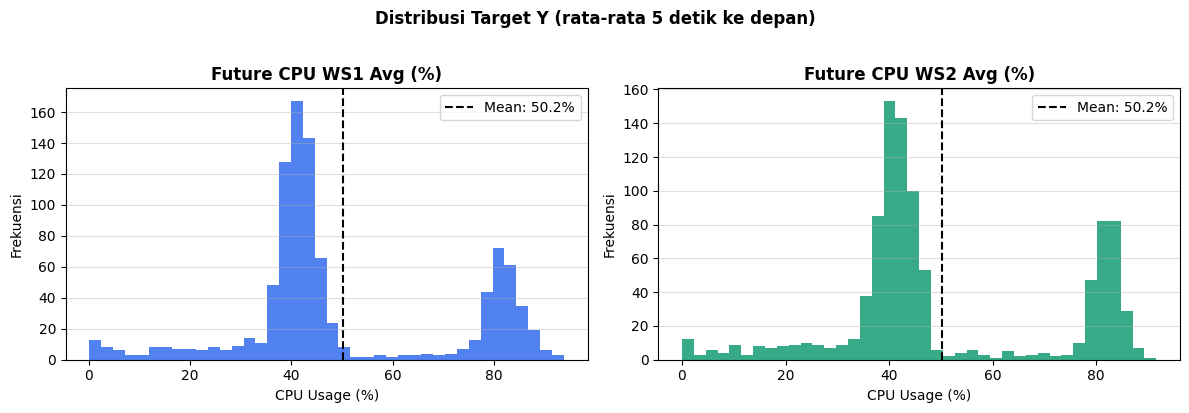


✅ Verifikasi anti-leakage:
   Fitur X  → diambil dari timestep T (kondisi sekarang)
   Target Y → diambil dari rata-rata CPU pada T+1 hingga T+5


In [115]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

SMOOTHING_WINDOW = 5  # rata-rata N detik ke depan

# ── Target Y: rata-rata CPU WS1 dan WS2 pada T+1, T+2, T+3
#    Ini adalah NILAI NUMERIK yang ingin diprediksi model,
#    bukan label 0/1. HAProxy LUA akan membandingkan kedua
#    nilai ini dengan threshold 5% untuk membuat keputusan routing.
df['future_cpu_ws1_avg'] = (
    df['cpu_ws1'].shift(-1) +
    df['cpu_ws1'].shift(-2) +
    df['cpu_ws1'].shift(-3) +
    df['cpu_ws1'].shift(-4) +
    df['cpu_ws1'].shift(-5)
) / SMOOTHING_WINDOW

df['future_cpu_ws2_avg'] = (
    df['cpu_ws2'].shift(-1) +
    df['cpu_ws2'].shift(-2) +
    df['cpu_ws2'].shift(-3) +
    df['cpu_ws2'].shift(-4) +
    df['cpu_ws2'].shift(-5)
) / SMOOTHING_WINDOW

# Hapus baris ujung yang tidak punya data masa depan (NaN akibat shift)
df.dropna(subset=['future_cpu_ws1_avg', 'future_cpu_ws2_avg'], inplace=True)
df.reset_index(drop=True, inplace=True)

#Filter fase jenuh: buang baris di mana kedua server sudah sangat sibuk (≥98% CPU)
# jml_sebelum = len(df)
# df = df[~((df['cpu_ws1'] >= 98) & (df['cpu_ws2'] >= 98))]
# df.reset_index(drop=True, inplace=True)
# jml_sesudah = len(df)

# print(f'=== Proses Pembersihan Data Fase Jenuh ===')
# print(f'  Data awal       : {jml_sebelum} baris')
# print(f'  Data terbuang   : {jml_sebelum - jml_sesudah} baris (Fase mentok 100%)')
# print(f'  Data bersih     : {jml_sesudah} baris (Golden Dataset)\n')

print(f'=== Target Y — Future CPU Average ({SMOOTHING_WINDOW} detik ke depan) ===')
print(f'  Total sampel : {len(df)}')
print(f'\n  future_cpu_ws1_avg:')
print(f'    Min   : {df["future_cpu_ws1_avg"].min():.2f}%')
print(f'    Max   : {df["future_cpu_ws1_avg"].max():.2f}%')
print(f'    Mean  : {df["future_cpu_ws1_avg"].mean():.2f}%')
print(f'    Std   : {df["future_cpu_ws1_avg"].std():.2f}%')
print(f'\n  future_cpu_ws2_avg:')
print(f'    Min   : {df["future_cpu_ws2_avg"].min():.2f}%')
print(f'    Max   : {df["future_cpu_ws2_avg"].max():.2f}%')
print(f'    Mean  : {df["future_cpu_ws2_avg"].mean():.2f}%')
print(f'    Std   : {df["future_cpu_ws2_avg"].std():.2f}%')

# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, color, title in zip(
    axes,
    ['future_cpu_ws1_avg', 'future_cpu_ws2_avg'],
    ['#2563EB', '#059669'],
    ['Future CPU WS1 Avg (%)', 'Future CPU WS2 Avg (%)']
):
    ax.hist(df[col], bins=40, color=color, alpha=0.8, edgecolor='none')
    ax.axvline(df[col].mean(), color='black', lw=1.5, linestyle='--',
               label=f'Mean: {df[col].mean():.1f}%')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('CPU Usage (%)')
    ax.set_ylabel('Frekuensi')
    ax.legend()
    ax.grid(axis='y', alpha=0.4)

plt.suptitle(f'Distribusi Target Y (rata-rata {SMOOTHING_WINDOW} detik ke depan)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('model2/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Verifikasi anti-leakage:')
print(f'   Fitur X  → diambil dari timestep T (kondisi sekarang)')
print(f'   Target Y → diambil dari rata-rata CPU pada T+1 hingga T+{SMOOTHING_WINDOW}')

---
## Step 9 — Persiapan Fitur (X) dan Target (Y)

In [116]:
# Kolom fitur — sama seperti sebelumnya, tidak ada fitur masa depan di sini
FEATURE_COLS = [
    # Metrik server mentah
    'cpu_ws1', 'ram_ws1', 'net_ws1',
    'cpu_ws2', 'ram_ws2', 'net_ws2',
    # Fitur selisih antar server
    'cpu_diff', 'ram_diff', 'net_diff', 'load_diff',
    # Load score composite
    'load_ws1', 'load_ws2',
    # Metrik performa JMeter
    # 'avg_rt', 'total_req', 'error_rate',
    # Rolling features (tren jangka pendek)
    'cpu_ws1_roll5', 'cpu_ws2_roll5',
    'rt_roll5', 'load_ws1_roll5', 'load_ws2_roll5',
]

# Dua kolom target (multi-output)
TARGET_COLS = ['future_cpu_ws1_avg', 'future_cpu_ws2_avg']

X = df[FEATURE_COLS].copy()
y = df[TARGET_COLS].copy()

print(f'Jumlah fitur  (X): {X.shape[1]}')
print(f'Jumlah target (Y): {y.shape[1]} → {TARGET_COLS}')
print(f'Jumlah sampel    : {X.shape[0]}')
print(f'\nDaftar fitur:')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {col}')

Jumlah fitur  (X): 17
Jumlah target (Y): 2 → ['future_cpu_ws1_avg', 'future_cpu_ws2_avg']
Jumlah sampel    : 987

Daftar fitur:
   1. cpu_ws1
   2. ram_ws1
   3. net_ws1
   4. cpu_ws2
   5. ram_ws2
   6. net_ws2
   7. cpu_diff
   8. ram_diff
   9. net_diff
  10. load_diff
  11. load_ws1
  12. load_ws2
  13. cpu_ws1_roll5
  14. cpu_ws2_roll5
  15. rt_roll5
  16. load_ws1_roll5
  17. load_ws2_roll5


---
## Step 10 — Train / Test Split

In [117]:
from sklearn.model_selection import train_test_split

# shuffle=False — wajib untuk time-series, menjaga urutan waktu
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    shuffle      = False,
    random_state = 42
)

print(f'Training set : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Testing set  : {X_test.shape[0]} sampel  ({X_test.shape[0]/len(X)*100:.0f}%)')

Training set : 789 sampel (80%)
Testing set  : 198 sampel  (20%)


---
## Step 11 — Training Model: MultiOutputRegressor + XGBRegressor

In [118]:
import joblib
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

# XGBRegressor sebagai base estimator
# MultiOutputRegressor melatih satu model XGB per target secara independen:
#   - Model 1 → memprediksi future_cpu_ws1_avg
#   - Model 2 → memprediksi future_cpu_ws2_avg
base_regressor = XGBRegressor(
    n_estimators     = 100,
    max_depth        = 4,
    learning_rate    = 0.05,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    min_child_weight = 5,
    gamma            = 0.1,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    objective        = 'reg:squarederror',
    random_state     = 42,
    verbosity        = 0
)

model = MultiOutputRegressor(base_regressor, n_jobs=-1)

print('Training model...')
model.fit(X_train, y_train)
print('\n✅ Training selesai.')
print(f'   Jumlah estimator internal : {len(model.estimators_)}')
print(f'   Target 0 → future_cpu_ws1_avg')
print(f'   Target 1 → future_cpu_ws2_avg')

Training model...

✅ Training selesai.
   Jumlah estimator internal : 2
   Target 0 → future_cpu_ws1_avg
   Target 1 → future_cpu_ws2_avg


---
## Step 12 — Evaluasi: RMSE, MAE, dan R² per Target

In [119]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prediksi pada test set
y_pred = model.predict(X_test)  # shape: (n_samples, 2)

y_pred_ws1 = y_pred[:, 0]  # prediksi future_cpu_ws1_avg
y_pred_ws2 = y_pred[:, 1]  # prediksi future_cpu_ws2_avg
y_true_ws1 = y_test['future_cpu_ws1_avg'].values
y_true_ws2 = y_test['future_cpu_ws2_avg'].values

# Hitung metrik per target
rmse_ws1 = np.sqrt(mean_squared_error(y_true_ws1, y_pred_ws1))
rmse_ws2 = np.sqrt(mean_squared_error(y_true_ws2, y_pred_ws2))
mae_ws1  = mean_absolute_error(y_true_ws1, y_pred_ws1)
mae_ws2  = mean_absolute_error(y_true_ws2, y_pred_ws2)
r2_ws1   = r2_score(y_true_ws1, y_pred_ws1)
r2_ws2   = r2_score(y_true_ws2, y_pred_ws2)

print('=' * 55)
print('  EVALUASI MODEL — Multi-Output Regression')
print('=' * 55)
print(f"  {'Metrik':<12}  {'WS1':>10}  {'WS2':>10}")
print(f"  {'-'*36}")
print(f"  {'RMSE':<12}  {rmse_ws1:>9.4f}%  {rmse_ws2:>9.4f}%")
print(f"  {'MAE':<12}  {mae_ws1:>9.4f}%  {mae_ws2:>9.4f}%")
print(f"  {'R2':<12}  {r2_ws1:>10.4f}  {r2_ws2:>10.4f}")
print('=' * 55)
print(f'\n  Interpretasi RMSE:')
print(f'    Prediksi CPU WS1 meleset rata-rata ±{rmse_ws1:.2f}%')
print(f'    Prediksi CPU WS2 meleset rata-rata ±{rmse_ws2:.2f}%')
print(f'\n  Catatan threshold HAProxy:')
print(f'    Threshold 5% akan efektif jika RMSE < 5%')
if rmse_ws1 < 5.0 and rmse_ws2 < 5.0:
    print(f'    ✅ RMSE kedua server di bawah 5% — threshold aman digunakan')
else:
    print(f'    ⚠️  RMSE > 5% pada satu atau dua server — threshold perlu disesuaikan')

  EVALUASI MODEL — Multi-Output Regression
  Metrik               WS1         WS2
  ------------------------------------
  RMSE             3.6355%     3.7981%
  MAE              2.9472%     3.0741%
  R2                0.6081      0.6091

  Interpretasi RMSE:
    Prediksi CPU WS1 meleset rata-rata ±3.64%
    Prediksi CPU WS2 meleset rata-rata ±3.80%

  Catatan threshold HAProxy:
    Threshold 5% akan efektif jika RMSE < 5%
    ✅ RMSE kedua server di bawah 5% — threshold aman digunakan


---
## Step 13 — Visualisasi Evaluasi

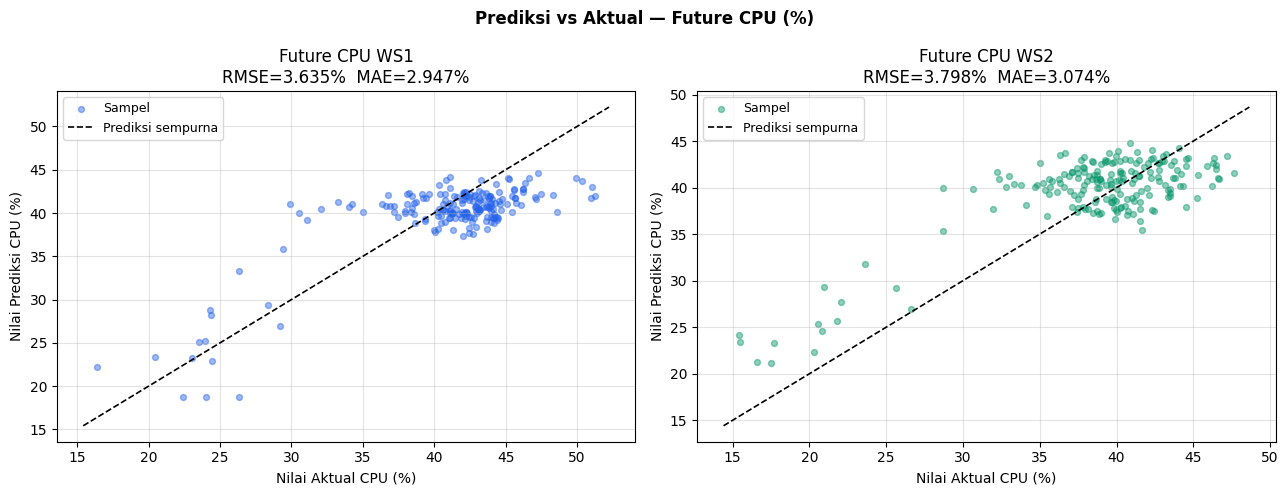

✅ Disimpan → model2/scatter_pred_vs_actual.png


In [120]:
# ── Plot 1: Prediksi vs Aktual (scatter + garis ideal)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Prediksi vs Aktual — Future CPU (%)', fontweight='bold')

for ax, y_true, y_p, label, color, rmse, mae in zip(
    axes,
    [y_true_ws1, y_true_ws2],
    [y_pred_ws1, y_pred_ws2],
    ['WS1', 'WS2'],
    ['#2563EB', '#059669'],
    [rmse_ws1, rmse_ws2],
    [mae_ws1,  mae_ws2]
):
    ax.scatter(y_true, y_p, alpha=0.45, s=18, color=color, label='Sampel')
    # Garis ideal (prediksi sempurna)
    lims = [min(y_true.min(), y_p.min()) - 1, max(y_true.max(), y_p.max()) + 1]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Prediksi sempurna')
    ax.set_xlabel('Nilai Aktual CPU (%)')
    ax.set_ylabel('Nilai Prediksi CPU (%)')
    ax.set_title(f'Future CPU {label}\nRMSE={rmse:.3f}%  MAE={mae:.3f}%')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.35)

plt.tight_layout()
plt.savefig('model2/scatter_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan → model2/scatter_pred_vs_actual.png')

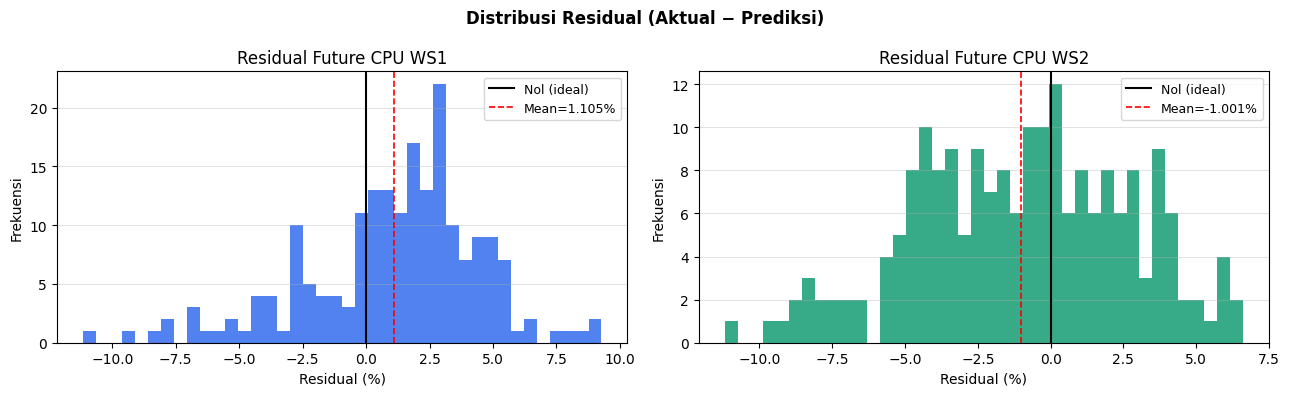

✅ Disimpan → model2/residual_distribution.png


In [121]:
# ── Plot 2: Residual (error) distribution per target
residual_ws1 = y_true_ws1 - y_pred_ws1
residual_ws2 = y_true_ws2 - y_pred_ws2

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Distribusi Residual (Aktual − Prediksi)', fontweight='bold')

for ax, res, label, color in zip(
    axes,
    [residual_ws1, residual_ws2],
    ['WS1', 'WS2'],
    ['#2563EB', '#059669']
):
    ax.hist(res, bins=40, color=color, alpha=0.80, edgecolor='none')
    ax.axvline(0,        color='black', lw=1.5, linestyle='-',  label='Nol (ideal)')
    ax.axvline(res.mean(), color='red', lw=1.2, linestyle='--', label=f'Mean={res.mean():.3f}%')
    ax.set_title(f'Residual Future CPU {label}')
    ax.set_xlabel('Residual (%)')
    ax.set_ylabel('Frekuensi')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig('model2/residual_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan → model2/residual_distribution.png')

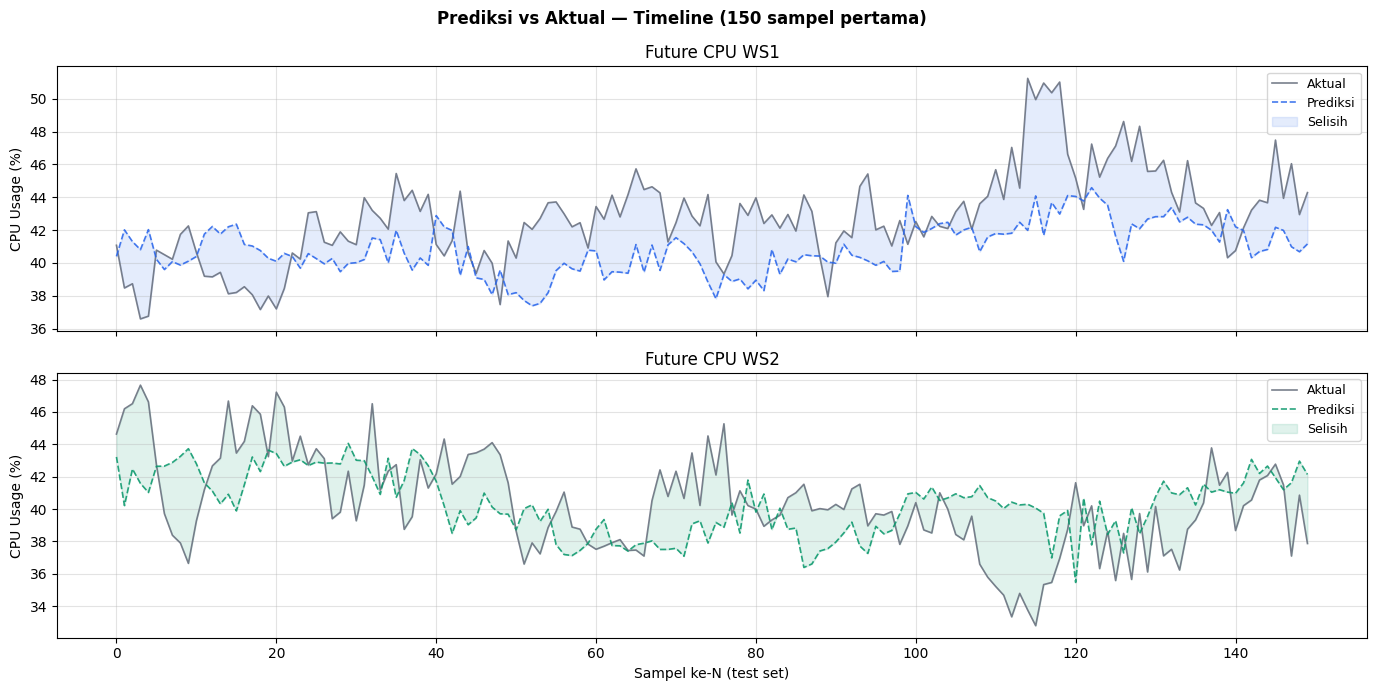

✅ Disimpan → model2/timeline_pred_vs_actual.png


In [122]:
# ── Plot 3: Prediksi vs Aktual over time (time-series style)
n_show = min(150, len(y_test))
x_axis = range(n_show)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
fig.suptitle('Prediksi vs Aktual — Timeline (150 sampel pertama)', fontweight='bold')

for ax, y_true, y_p, label, color in zip(
    axes,
    [y_true_ws1, y_true_ws2],
    [y_pred_ws1, y_pred_ws2],
    ['WS1', 'WS2'],
    ['#2563EB', '#059669']
):
    ax.plot(x_axis, y_true[:n_show], color='#6B7280', lw=1.2,
            label='Aktual', alpha=0.9)
    ax.plot(x_axis, y_p[:n_show],    color=color,    lw=1.2,
            label='Prediksi', alpha=0.85, linestyle='--')
    ax.fill_between(x_axis,
                    y_true[:n_show],
                    y_p[:n_show],
                    alpha=0.12, color=color, label='Selisih')
    ax.set_ylabel('CPU Usage (%)')
    ax.set_title(f'Future CPU {label}')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.35)

axes[-1].set_xlabel('Sampel ke-N (test set)')
plt.tight_layout()
plt.savefig('model2/timeline_pred_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan → model2/timeline_pred_vs_actual.png')

Menghitung learning curve (perlu beberapa saat)...


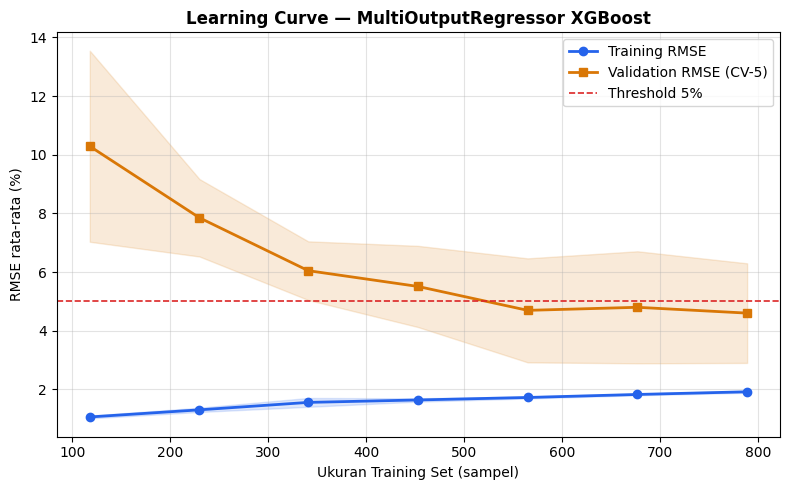

✅ Disimpan → model2/learning_curve.png


In [123]:
# ── Plot 4: Learning Curve (RMSE vs ukuran training set)
#    Menunjukkan apakah model butuh lebih banyak data atau sudah cukup
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer

def rmse_scorer(estimator, X, y):
    """Custom scorer RMSE rata-rata dari kedua target."""
    y_p = estimator.predict(X)
    rmse_0 = np.sqrt(mean_squared_error(y.iloc[:, 0], y_p[:, 0]))
    rmse_1 = np.sqrt(mean_squared_error(y.iloc[:, 1], y_p[:, 1]))
    # Kembalikan negatif karena learning_curve memaksimalkan skor
    return -np.mean([rmse_0, rmse_1])

print('Menghitung learning curve (perlu beberapa saat)...')
train_sizes, train_scores, val_scores = learning_curve(
    model,
    X, y,
    train_sizes = np.linspace(0.15, 1.0, 7),
    cv          = 5,
    scoring     = rmse_scorer,
    n_jobs      = -1,
    shuffle     = False
)

# Balik tanda negatif untuk tampilan
train_rmse_mean = -train_scores.mean(axis=1)
train_rmse_std  =  train_scores.std(axis=1)
val_rmse_mean   = -val_scores.mean(axis=1)
val_rmse_std    =  val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sizes, train_rmse_mean, 'o-', color='#2563EB', lw=2, label='Training RMSE')
ax.fill_between(train_sizes,
                train_rmse_mean - train_rmse_std,
                train_rmse_mean + train_rmse_std,
                alpha=0.15, color='#2563EB')
ax.plot(train_sizes, val_rmse_mean, 's-', color='#D97706', lw=2, label='Validation RMSE (CV-5)')
ax.fill_between(train_sizes,
                val_rmse_mean - val_rmse_std,
                val_rmse_mean + val_rmse_std,
                alpha=0.15, color='#D97706')
ax.axhline(5.0, color='#DC2626', lw=1.2, linestyle='--', label='Threshold 5%')
ax.set_xlabel('Ukuran Training Set (sampel)')
ax.set_ylabel('RMSE rata-rata (%)')
ax.set_title('Learning Curve — MultiOutputRegressor XGBoost', fontweight='bold')
ax.legend()
ax.grid(alpha=0.35)
plt.tight_layout()
plt.savefig('model2/learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan → model2/learning_curve.png')

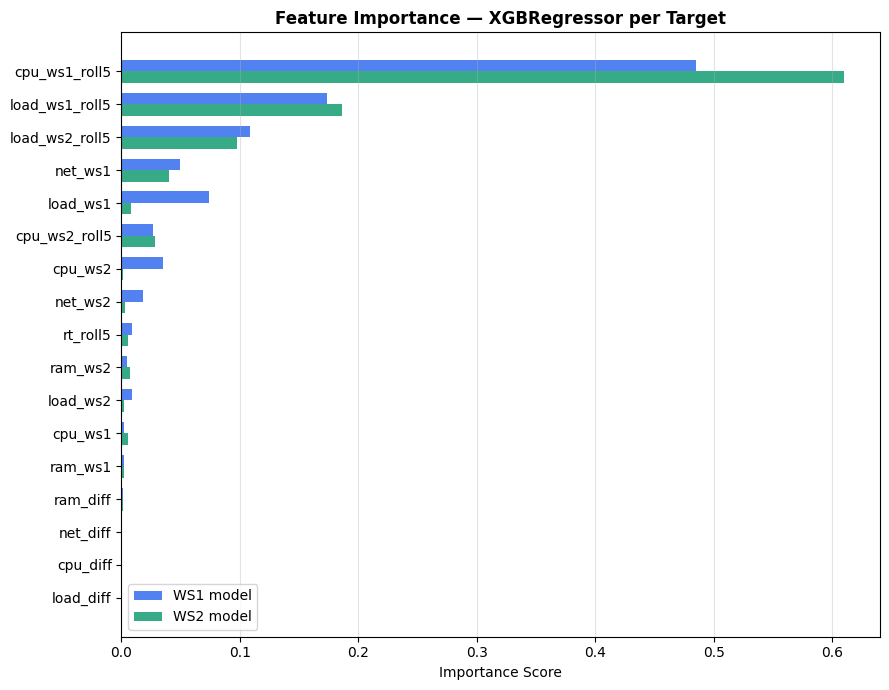

✅ Disimpan → model2/feature_importance.png


In [124]:
# ── Plot 5: Feature Importance (rata-rata dari dua estimator internal)
imp_ws1 = model.estimators_[0].feature_importances_
imp_ws2 = model.estimators_[1].feature_importances_
imp_avg = (imp_ws1 + imp_ws2) / 2

feat_imp_df = pd.DataFrame({
    'Feature'    : FEATURE_COLS,
    'WS1'        : imp_ws1,
    'WS2'        : imp_ws2,
    'Average'    : imp_avg,
}).sort_values('Average', ascending=True)

fig, ax = plt.subplots(figsize=(9, 7))
x_pos  = np.arange(len(feat_imp_df))
width  = 0.35
ax.barh(x_pos + width/2, feat_imp_df['WS1'], width,
        color='#2563EB', alpha=0.80, label='WS1 model')
ax.barh(x_pos - width/2, feat_imp_df['WS2'], width,
        color='#059669', alpha=0.80, label='WS2 model')
ax.set_yticks(x_pos)
ax.set_yticklabels(feat_imp_df['Feature'])
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance — XGBRegressor per Target', fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.35)
plt.tight_layout()
plt.savefig('model2/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Disimpan → model2/feature_importance.png')

---
## Step 14 — Export Model ke .pkl

In [125]:
import os

PATH_MODEL = 'model2/xgb_load_balancer.pkl'

# Simpan satu objek yang berisi semua yang dibutuhkan saat inferensi
export_bundle = {
    'model'       : model,           # MultiOutputRegressor
    'feature_cols': FEATURE_COLS,    # urutan fitur — wajib sama dengan api.py
    'target_cols' : TARGET_COLS,     # ['future_cpu_ws1_avg', 'future_cpu_ws2_avg']
    'norm_constants': {
        'RAM_MAX': RAM_MAX,
        'NET_MAX': NET_MAX
    },
    'smoothing_window': SMOOTHING_WINDOW,
}

joblib.dump(export_bundle, PATH_MODEL)

print(f'✅ Model bundle disimpan ke: {PATH_MODEL}')
print(f'   Ukuran file : {os.path.getsize(PATH_MODEL) / 1024:.1f} KB')
print(f'\n   Isi bundle:')
print(f'     model          → MultiOutputRegressor(XGBRegressor)')
print(f'     feature_cols   → {len(FEATURE_COLS)} fitur')
print(f'     target_cols    → {TARGET_COLS}')
print(f'     norm_constants → RAM_MAX={RAM_MAX:.1f}, NET_MAX={NET_MAX:.1f}')
print(f'     smoothing_window → {SMOOTHING_WINDOW}')

✅ Model bundle disimpan ke: model2/xgb_load_balancer.pkl
   Ukuran file : 299.9 KB

   Isi bundle:
     model          → MultiOutputRegressor(XGBRegressor)
     feature_cols   → 17 fitur
     target_cols    → ['future_cpu_ws1_avg', 'future_cpu_ws2_avg']
     norm_constants → RAM_MAX=433.9, NET_MAX=8522.5
     smoothing_window → 5


---
## Step 15 — Uji Coba Inferensi (Simulasi Real-Time)

In [126]:
# Load bundle dari file .pkl
bundle          = joblib.load(PATH_MODEL)
loaded_model    = bundle['model']
loaded_features = bundle['feature_cols']
loaded_norms    = bundle['norm_constants']
RAM_MAX_l       = loaded_norms['RAM_MAX']
NET_MAX_l       = loaded_norms['NET_MAX']

# ── Simulasikan input real-time dari metrics_agent.py
cpu_ws1 = 72.5;  ram_ws1 = 850.0;  net_ws1 = 120.0
cpu_ws2 = 35.2;  ram_ws2 = 620.0;  net_ws2 = 95.0
avg_rt  = 320.0; total_req = 25;   error_rate = 0.0

# Hitung load score (harus pakai konstanta dari training)
load_ws1 = 0.50*cpu_ws1 + 0.30*(ram_ws1/RAM_MAX_l*100) + 0.20*min(net_ws1/NET_MAX_l*100, 100)
load_ws2 = 0.50*cpu_ws2 + 0.30*(ram_ws2/RAM_MAX_l*100) + 0.20*min(net_ws2/NET_MAX_l*100, 100)

sample = {
    'cpu_ws1': cpu_ws1, 'ram_ws1': ram_ws1, 'net_ws1': net_ws1,
    'cpu_ws2': cpu_ws2, 'ram_ws2': ram_ws2, 'net_ws2': net_ws2,
    'cpu_diff': cpu_ws1 - cpu_ws2,
    'ram_diff': ram_ws1 - ram_ws2,
    'net_diff': net_ws1 - net_ws2,
    'load_diff': load_ws1 - load_ws2,
    'load_ws1': load_ws1, 'load_ws2': load_ws2,
    'avg_rt': avg_rt, 'total_req': total_req, 'error_rate': error_rate,
    # Rolling: gunakan nilai saat ini sebagai aproksimasi
    'cpu_ws1_roll5': cpu_ws1, 'cpu_ws2_roll5': cpu_ws2,
    'rt_roll5': avg_rt, 'load_ws1_roll5': load_ws1, 'load_ws2_roll5': load_ws2,
}

X_input   = pd.DataFrame([sample])[loaded_features]
prediction = loaded_model.predict(X_input)[0]  # [pred_ws1_cpu, pred_ws2_cpu]

pred_cpu_ws1 = prediction[0]
pred_cpu_ws2 = prediction[1]
selisih      = abs(pred_cpu_ws1 - pred_cpu_ws2)
THRESHOLD    = 5.0  # persen — nilai ini yang dipakai di LUA script

print('=== Hasil Inferensi ===')
print(f'  CPU saat ini  → WS1: {cpu_ws1}% | WS2: {cpu_ws2}%')
print(f'  Prediksi CPU  → WS1: {pred_cpu_ws1:.2f}% | WS2: {pred_cpu_ws2:.2f}%')
print(f'  Selisih prediksi: {selisih:.2f}%')
print()

if selisih >= THRESHOLD:
    server = 'WS1' if pred_cpu_ws1 < pred_cpu_ws2 else 'WS2'
    print(f'  Selisih ≥ {THRESHOLD}% → AI memutuskan route ke {server}')
else:
    print(f'  Selisih < {THRESHOLD}% → beban hampir sama, HAProxy boleh pakai fallback (RoundRobin)')

print()
print('  Format JSON yang akan dikembalikan api.py ke HAProxy LUA:')
print(f'  {{')
print(f'    "pred_cpu_ws1": {pred_cpu_ws1:.2f},')
print(f'    "pred_cpu_ws2": {pred_cpu_ws2:.2f},')
print(f'    "selisih"     : {selisih:.2f},')
print(f'    "recommended" : "{"ws1" if pred_cpu_ws1 < pred_cpu_ws2 else "ws2"}"')
print(f'  }}')

=== Hasil Inferensi ===
  CPU saat ini  → WS1: 72.5% | WS2: 35.2%
  Prediksi CPU  → WS1: 68.62% | WS2: 69.44%
  Selisih prediksi: 0.82%

  Selisih < 5.0% → beban hampir sama, HAProxy boleh pakai fallback (RoundRobin)

  Format JSON yang akan dikembalikan api.py ke HAProxy LUA:
  {
    "pred_cpu_ws1": 68.62,
    "pred_cpu_ws2": 69.44,
    "selisih"     : 0.82,
    "recommended" : "ws1"
  }


---
## Ringkasan Output

```
model/
├── xgb_load_balancer.pkl          ← bundle utama (model + metadata)
├── target_distribution.png        ← distribusi target Y
├── scatter_pred_vs_actual.png     ← prediksi vs aktual (scatter)
├── residual_distribution.png      ← distribusi error prediksi
├── timeline_pred_vs_actual.png    ← prediksi vs aktual (time-series)
├── learning_curve.png             ← apakah model butuh lebih banyak data?
└── feature_importance.png         ← kontribusi tiap fitur per target
```

### Catatan untuk api.py
Response endpoint `/predict` perlu diupdate untuk mengembalikan:
```json
{
  "pred_cpu_ws1": 72.50,
  "pred_cpu_ws2": 35.20,
  "selisih": 37.30,
  "recommended": "ws2"
}
```
HAProxy LUA script membaca `pred_cpu_ws1` dan `pred_cpu_ws2`, menghitung selisih,
dan melakukan routing hanya jika selisih ≥ 5%.